## Iterational Permutations


Processing instance: TSPinstances/pr76.tsp
Instance: pr76
Dimension: 76
Mu=1.0, Beta=1.0, Delta=1.0 => Avg Path Length: 110895.39898937536
Mu=1.0, Beta=1.0, Delta=1.5 => Avg Path Length: 110699.79715335183
Mu=1.0, Beta=1.0, Delta=2.0 => Avg Path Length: 111673.86730183141
Mu=1.0, Beta=1.0, Delta=2.5 => Avg Path Length: 110297.0464602233
Mu=1.0, Beta=1.0, Delta=3.0 => Avg Path Length: 111524.33153057119
Mu=1.0, Beta=1.5, Delta=1.0 => Avg Path Length: 110508.78443398292
Mu=1.0, Beta=1.5, Delta=1.5 => Avg Path Length: 110036.06574307042
Mu=1.0, Beta=1.5, Delta=2.0 => Avg Path Length: 110551.2664654996
Mu=1.0, Beta=1.5, Delta=2.5 => Avg Path Length: 111015.47274527718
Mu=1.0, Beta=1.5, Delta=3.0 => Avg Path Length: 110607.93873029035
Mu=1.0, Beta=2.0, Delta=1.0 => Avg Path Length: 110481.47479444319
Mu=1.0, Beta=2.0, Delta=1.5 => Avg Path Length: 109710.16759740678
Mu=1.0, Beta=2.0, Delta=2.0 => Avg Path Length: 110648.30570620252
Mu=1.0, Beta=2.0, Delta=2.5 => Avg Path Length: 109953.484

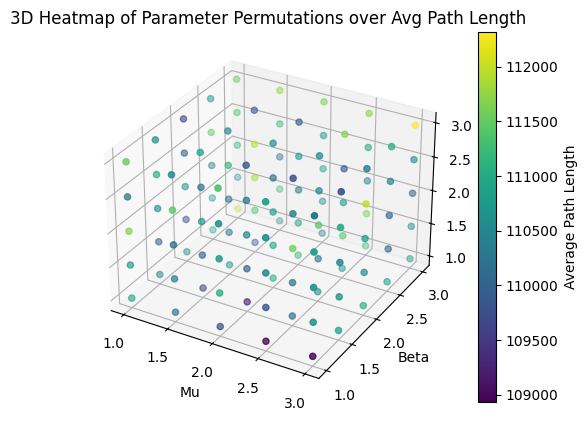

In [4]:
import os
import numpy as np
import random
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt


def read(instance_file):
    infile = open(instance_file, 'r')
    Name = infile.readline().strip().split()[2]  # NAME
    infile.readline().strip().split()[2]         # TYPE
    infile.readline().strip().split()[2]         # COMMENT
    Dimension = infile.readline().strip().split()[2]  # DIMENSION
    infile.readline().strip().split()[2]         # EDGE_WEIGHT_TYPE
    infile.readline() 
    print("Instance:", Name)
    print("Dimension:", Dimension)
    N = int(Dimension)
    nodelist = np.empty((N, 2))
    for i in range(N):
        _, x, y = infile.readline().strip().split()
        nodelist[i] = [float(x), float(y)]
    infile.close()
    return nodelist

def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        current_city = path[i]
        next_city = path[i + 1]
        path_length += distances[current_city][next_city]
    return path_length

def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)

def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    pheromone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu
    if mode == 0:
        return pheromone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return pheromone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp

def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, 0)
                      for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]

def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])

def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            current_city = path[i]
            next_city = path[i + 1]
            delta_pheromones[current_city][next_city] += rewards
    pheromones += -rho * pheromones + delta_pheromones

def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue  
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_path_length = calculate_path_length(new_path, distances)
                if new_path_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_path_length
                    improved = True
        path = best_path
    return best_path

def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants, num_local_search_iterations, 
                 gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate, w_reward, rho, delta, beta, mu):
    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))
    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)
        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))
                allowed_cities = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]
                if hop == num_cities - 1:
                    next_city = paths[ant][0]  # Complete cycle
                else:
                    next_city = choose_next_city(current_city, allowed_cities, q_table, pheromones, local_epsilon,
                                                  distances, delta, beta, mu)
                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]
            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)
        best_path_index = np.argmin(path_lengths)
        best_path = paths[best_path_index]
        best_path_length = path_lengths[best_path_index]
        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_path_length = calculate_path_length(new_path, distances)
            if new_path_length < best_path_length:
                best_path = new_path
                best_path_length = new_path_length
        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)
        local_alpha *= 1.0 / (1.0 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)
    return best_path


global_params = {
    "alpha": 0.5,               
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,               
    "epsilon": 1.0,              
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,                  
    "w_reward": 10,
    "num_local_search_iterations": 25,
    "mu": 2,                     
    "delta": 2,                 
    "beta": 3                   
}

def run_trial(trial, num_cities, distances, global_params):
    local_alpha = global_params["alpha"]
    local_epsilon = global_params["epsilon"]
    best_path = hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, 
                             global_params["num_episodes"], global_params["num_ants"],
                             global_params["num_local_search_iterations"], global_params["gamma"],
                             global_params["alpha_decay_rate"], global_params["epsilon_min"],
                             global_params["epsilon_decay_rate"], global_params["w_reward"],
                             global_params["rho"], global_params["delta"], global_params["beta"],
                             global_params["mu"])
    length = calculate_path_length(best_path, distances)
    return trial, best_path, length


instances_dir = 'TSPinstances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

if not instance_files:
    print("No TSP instance files found in directory:", instances_dir)
else:
    for instance_file in instance_files:
        print("\n" + "="*60)
        print("Processing instance:", instance_file)
        
        # Read the instance and compute the distance matrix.
        cities = read(instance_file)
        num_cities = len(cities)
        distances = np.zeros((num_cities, num_cities))
        for i in range(num_cities):
            for j in range(num_cities):
                x1, y1 = cities[i]
                x2, y2 = cities[j]
                distances[i][j] = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
        #Parameter Iterations
        mu_values = np.arange(1, 3.5, 0.5)
        beta_values = np.arange(1, 3.5, 0.5)
        delta_values = np.arange(1, 3.5, 0.5)
    
        param_results = []  
        num_trials = 5      
    
        #Iterating through all parameter combinations (125 in total)
        for mu in mu_values:
            for beta in beta_values:
                for delta in delta_values:
                    global_params['mu'] = mu
                    global_params['beta'] = beta
                    global_params['delta'] = delta
    
                    trial_lengths = []
                    with ProcessPoolExecutor(max_workers=num_trials) as executor:
                        futures = [
                            executor.submit(run_trial, trial, num_cities, distances, global_params)
                            for trial in range(1, num_trials + 1)
                        ]
                        for future in as_completed(futures):
                            trial, path, length = future.result()
                            trial_lengths.append(length)
    
                    avg_length = np.mean(trial_lengths)
                    param_results.append((mu, beta, delta, avg_length))
                    print(f"Mu={mu}, Beta={beta}, Delta={delta} => Avg Path Length: {avg_length}")
    
        #Convert results to a NumPy array for easier handling
        param_results = np.array(param_results)
        mu_list = param_results[:, 0]
        beta_list = param_results[:, 1]
        delta_list = param_results[:, 2]
        avg_lengths = param_results[:, 3]
    
        #Visualization: 3D Scatter Plot as a Heatmap
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(mu_list, beta_list, delta_list, c=avg_lengths, cmap='viridis')
        ax.set_xlabel('Mu')
        ax.set_ylabel('Beta')
        ax.set_zlabel('Delta')
        plt.colorbar(sc, label='Average Path Length')
        plt.title('3D Heatmap of Parameter Permutations over Avg Path Length')
        plt.show()


## Complete Code

In [1]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime

def read(instance_file):
    infile = open(instance_file, 'r')
    Name = infile.readline().strip().split()[2]  # NAME
    infile.readline().strip().split()[2]         # TYPE
    infile.readline().strip().split()[2]         # COMMENT
    Dimension = infile.readline().strip().split()[2]  # DIMENSION
    infile.readline().strip().split()[2]         # EDGE_WEIGHT_TYPE
    infile.readline()
    print("Instance:", Name)
    print("Dimension:", Dimension)
    N = int(Dimension)
    nodelist = np.empty((N, 2))
    for i in range(N):
        x, y = infile.readline().strip().split()[1:]
        nodelist[i] = [x, y]
    infile.close()
    return nodelist

def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        current_city = path[i]
        next_city = path[i + 1]
        path_length += distances[current_city][next_city]
    return path_length

def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)

def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu
    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp

def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, 0)
                      for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]

def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])

def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            current_city = path[i]
            next_city = path[i + 1]
            delta_pheromones[current_city][next_city] += rewards
    pheromones += -rho * pheromones + delta_pheromones

def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue  
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_path_length = calculate_path_length(new_path, distances)
                if new_path_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_path_length
                    improved = True
        path = best_path
    return best_path

def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants, num_local_search_iterations, 
                 gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate, w_reward, rho, delta, beta, mu):
    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))
    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)
        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))
                allowed_cities = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]
                if hop == num_cities - 1:
                    next_city = paths[ant][0]  # complete cycle
                else:
                    next_city = choose_next_city(current_city, allowed_cities, q_table, pheromones, local_epsilon,
                                                  distances, delta, beta, mu)
                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]
            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)
        best_path_index = np.argmin(path_lengths)
        best_path = paths[best_path_index]
        best_path_length = path_lengths[best_path_index]
        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_path_length = calculate_path_length(new_path, distances)
            if new_path_length < best_path_length:
                best_path = new_path
                best_path_length = new_path_length
        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)
        local_alpha *= 1.0 / (1.0 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)
    return best_path

# Global parameters (packaged into a dictionary for easy passing)
global_params = {
    "alpha": 0.5,                # Learning rate
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,               # Discount factor
    "epsilon": 1.0,              # Exploration rate
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,                  # Evaporation rate
    "w_reward": 10,
    "num_local_search_iterations": 25,
    "mu": 2,                     # Q-learning factor
    "delta": 2,                  # Pheromone factor
    "beta": 3                    # Heuristic factor
}

def run_trial(trial, num_cities, distances, global_params):
    local_alpha = global_params["alpha"]
    local_epsilon = global_params["epsilon"]
    best_path = hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, 
                             global_params["num_episodes"], global_params["num_ants"],
                             global_params["num_local_search_iterations"], global_params["gamma"],
                             global_params["alpha_decay_rate"], global_params["epsilon_min"],
                             global_params["epsilon_decay_rate"], global_params["w_reward"],
                             global_params["rho"], global_params["delta"], global_params["beta"],
                             global_params["mu"])
    length = calculate_path_length(best_path, distances)
    return trial, best_path, length

instances_dir = 'TSPinstances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

for instance_file in instance_files:
    print("\n" + "="*60)
    print("Processing instance:", instance_file)
    
    cities = read(instance_file)
    num_cities = len(cities)
    distances = np.zeros((num_cities, num_cities))
    for i in range(num_cities):
        for j in range(num_cities):
            x1, y1 = cities[i]
            x2, y2 = cities[j]
            distances[i][j] = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    num_trials = 5
    results = []
    
    start_time = datetime.now()
    print(f"\nStart Time: {start_time}\n{'='*40}")
    
    with ProcessPoolExecutor(max_workers=num_trials) as executor:
        futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                   for trial in range(1, num_trials+1)]
        for future in as_completed(futures):
            trial, path, length = future.result()
            results.append((trial, path, length))
    
    results.sort(key=lambda x: x[0])
    for trial, path, length in results:
        print(f"\nTrial {trial}:\nOptimal Path Length: {length}\n{'-'*40}")
    
    avg_length = np.mean([length for _, _, length in results])
    print(f"\nAverage Optimal Path Length: {avg_length}")
    
    end_time = datetime.now()
    print(f"\nEnd Time: {end_time}")
    total_time = (end_time - start_time).total_seconds()
    print(f"Total Time Taken for instance: {total_time} seconds")



Processing instance: TSPinstances/rd100.tsp
Instance: rd100
Dimension: 100

Start Time: 2025-03-18 13:06:58.493878

Trial 1:
Optimal Path Length: 8310.756141861772
----------------------------------------

Trial 2:
Optimal Path Length: 8067.511247913608
----------------------------------------

Trial 3:
Optimal Path Length: 8122.6905894264655
----------------------------------------

Trial 4:
Optimal Path Length: 8010.360014818189
----------------------------------------

Trial 5:
Optimal Path Length: 8093.916301745237
----------------------------------------

Average Optimal Path Length: 8121.046859153054

End Time: 2025-03-18 13:12:11.435957
Total Time Taken for instance: 312.942079 seconds


## Q-learning + 2Opt (ACO Removed)

In [1]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime

def read(instance_file):
    infile = open(instance_file, 'r')
    Name = infile.readline().strip().split()[2]  # NAME
    infile.readline().strip().split()[2]         # TYPE
    infile.readline().strip().split()[2]         # COMMENT
    Dimension = infile.readline().strip().split()[2]  # DIMENSION
    infile.readline().strip().split()[2]         # EDGE_WEIGHT_TYPE
    infile.readline()
    print("Instance:", Name)
    print("Dimension:", Dimension)
    N = int(Dimension)
    nodelist = np.empty((N, 2))
    for i in range(N):
        x, y = infile.readline().strip().split()[1:]
        nodelist[i] = [x, y]
    infile.close()
    return nodelist

def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        current_city = path[i]
        next_city = path[i + 1]
        path_length += distances[current_city][next_city]
    return path_length

def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)

def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu
    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp

def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, 0)
                      for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]

def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])

def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            current_city = path[i]
            next_city = path[i + 1]
            delta_pheromones[current_city][next_city] += rewards
    pheromones += -rho * pheromones + delta_pheromones

def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue 
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_path_length = calculate_path_length(new_path, distances)
                if new_path_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_path_length
                    improved = True
        path = best_path
    return best_path

def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants, num_local_search_iterations, 
                 gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate, w_reward, rho, delta, beta, mu):
    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))
    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)
        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))
                allowed_cities = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]
                if hop == num_cities - 1:
                    next_city = paths[ant][0] 
                else:
                    next_city = choose_next_city(current_city, allowed_cities, q_table, pheromones, local_epsilon,
                                                  distances, delta, beta, mu)
                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]
            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)
        best_path_index = np.argmin(path_lengths)
        best_path = paths[best_path_index]
        best_path_length = path_lengths[best_path_index]
        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_path_length = calculate_path_length(new_path, distances)
            if new_path_length < best_path_length:
                best_path = new_path
                best_path_length = new_path_length
        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)
        local_alpha *= 1.0 / (1.0 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)
    return best_path

global_params = {
    "alpha": 0.5,                # Learning rate
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,               # Discount factor
    "epsilon": 1.0,              # Exploration rate
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,                  # Evaporation rate
    "w_reward": 10,
    "num_local_search_iterations": 25,
    "mu": 2,                     # Q-learning factor
    "delta": 0,                  # Pheromone factor
    "beta": 3                    # Heuristic factor
}

def run_trial(trial, num_cities, distances, global_params):
    local_alpha = global_params["alpha"]
    local_epsilon = global_params["epsilon"]
    best_path = hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, 
                             global_params["num_episodes"], global_params["num_ants"],
                             global_params["num_local_search_iterations"], global_params["gamma"],
                             global_params["alpha_decay_rate"], global_params["epsilon_min"],
                             global_params["epsilon_decay_rate"], global_params["w_reward"],
                             global_params["rho"], global_params["delta"], global_params["beta"],
                             global_params["mu"])
    length = calculate_path_length(best_path, distances)
    return trial, best_path, length

instances_dir = 'TSPinstances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

for instance_file in instance_files:
    print("\n" + "="*60)
    print("Processing instance:", instance_file)
    
    cities = read(instance_file)
    num_cities = len(cities)
    distances = np.zeros((num_cities, num_cities))
    for i in range(num_cities):
        for j in range(num_cities):
            x1, y1 = cities[i]
            x2, y2 = cities[j]
            distances[i][j] = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    num_trials = 5
    results = []
    
    start_time = datetime.now()
    print(f"\nStart Time: {start_time}\n{'='*40}")
    
    with ProcessPoolExecutor(max_workers=num_trials) as executor:
        futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                   for trial in range(1, num_trials+1)]
        for future in as_completed(futures):
            trial, path, length = future.result()
            results.append((trial, path, length))
    
    results.sort(key=lambda x: x[0])
    for trial, path, length in results:
        print(f"\nTrial {trial}:\nOptimal Path Length: {length}\n{'-'*40}")
    
    avg_length = np.mean([length for _, _, length in results])
    print(f"\nAverage Optimal Path Length: {avg_length}")
    
    end_time = datetime.now()
    print(f"\nEnd Time: {end_time}")
    total_time = (end_time - start_time).total_seconds()
    print(f"Total Time Taken for instance: {total_time} seconds")



Processing instance: TSPinstances/pr226.tsp
Instance: pr226
Dimension: 226

Start Time: 2025-03-14 08:47:52.252668

Trial 1:
Optimal Path Length: 84396.57572359341
----------------------------------------

Trial 2:
Optimal Path Length: 85231.26415293699
----------------------------------------

Trial 3:
Optimal Path Length: 86110.51894179356
----------------------------------------

Trial 4:
Optimal Path Length: 86731.55045508323
----------------------------------------

Trial 5:
Optimal Path Length: 86259.75517982461
----------------------------------------

Average Optimal Path Length: 85745.93289064636

End Time: 2025-03-14 12:57:09.965669
Total Time Taken for instance: 14957.713001 seconds

Processing instance: TSPinstances/ts225.tsp
Instance: ts225
Dimension: 225

Start Time: 2025-03-14 12:57:10.085849

Trial 1:
Optimal Path Length: 128982.36794840734
----------------------------------------

Trial 2:
Optimal Path Length: 131601.5385109858
----------------------------------------

## Q-learning + ACO (2-Opt Removed)

In [2]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime

def read(instance_file):
    infile = open(instance_file, 'r')
    Name = infile.readline().strip().split()[2]  # NAME
    infile.readline().strip().split()[2]         # TYPE
    infile.readline().strip().split()[2]         # COMMENT
    Dimension = infile.readline().strip().split()[2]  # DIMENSION
    infile.readline().strip().split()[2]         # EDGE_WEIGHT_TYPE
    infile.readline()
    print("Instance:", Name)
    print("Dimension:", Dimension)
    N = int(Dimension)
    nodelist = np.empty((N, 2))
    for i in range(N):
        x, y = infile.readline().strip().split()[1:]
        nodelist[i] = [x, y]
    infile.close()
    return nodelist

def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        current_city = path[i]
        next_city = path[i + 1]
        path_length += distances[current_city][next_city]
    return path_length

def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)

def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu
    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp

def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, 0)
                      for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]

def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])

def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            current_city = path[i]
            next_city = path[i + 1]
            delta_pheromones[current_city][next_city] += rewards
    pheromones += -rho * pheromones + delta_pheromones

def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue  
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_path_length = calculate_path_length(new_path, distances)
                if new_path_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_path_length
                    improved = True
        path = best_path
    return best_path

def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants, num_local_search_iterations, 
                 gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate, w_reward, rho, delta, beta, mu):
    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))
    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)
        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))
                allowed_cities = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]
                if hop == num_cities - 1:
                    next_city = paths[ant][0]  
                else:
                    next_city = choose_next_city(current_city, allowed_cities, q_table, pheromones, local_epsilon,
                                                  distances, delta, beta, mu)
                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]
            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)
        best_path_index = np.argmin(path_lengths)
        best_path = paths[best_path_index]
        best_path_length = path_lengths[best_path_index]
        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_path_length = calculate_path_length(new_path, distances)
            if new_path_length < best_path_length:
                best_path = new_path
                best_path_length = new_path_length
        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)
        local_alpha *= 1.0 / (1.0 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)
    return best_path

global_params = {
    "alpha": 0.5,                # Learning rate
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,               # Discount factor
    "epsilon": 1.0,              # Exploration rate
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,                  # Evaporation rate
    "w_reward": 10,
    "num_local_search_iterations": 0,
    "mu": 2,                     # Q-learning factor
    "delta": 2,                  # Pheromone factor
    "beta": 3                    # Heuristic factor
}

def run_trial(trial, num_cities, distances, global_params):
    local_alpha = global_params["alpha"]
    local_epsilon = global_params["epsilon"]
    best_path = hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, 
                             global_params["num_episodes"], global_params["num_ants"],
                             global_params["num_local_search_iterations"], global_params["gamma"],
                             global_params["alpha_decay_rate"], global_params["epsilon_min"],
                             global_params["epsilon_decay_rate"], global_params["w_reward"],
                             global_params["rho"], global_params["delta"], global_params["beta"],
                             global_params["mu"])
    length = calculate_path_length(best_path, distances)
    return trial, best_path, length

instances_dir = 'TSPinstances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

for instance_file in instance_files:
    print("\n" + "="*60)
    print("Processing instance:", instance_file)
    
    cities = read(instance_file)
    num_cities = len(cities)
    distances = np.zeros((num_cities, num_cities))
    for i in range(num_cities):
        for j in range(num_cities):
            x1, y1 = cities[i]
            x2, y2 = cities[j]
            distances[i][j] = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    num_trials = 5
    results = []
    
    start_time = datetime.now()
    print(f"\nStart Time: {start_time}\n{'='*40}")
    
    with ProcessPoolExecutor(max_workers=num_trials) as executor:
        futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                   for trial in range(1, num_trials+1)]
        for future in as_completed(futures):
            trial, path, length = future.result()
            results.append((trial, path, length))
    
    results.sort(key=lambda x: x[0])
    for trial, path, length in results:
        print(f"\nTrial {trial}:\nOptimal Path Length: {length}\n{'-'*40}")
    
    avg_length = np.mean([length for _, _, length in results])
    print(f"\nAverage Optimal Path Length: {avg_length}")
    
    end_time = datetime.now()
    print(f"\nEnd Time: {end_time}")
    total_time = (end_time - start_time).total_seconds()
    print(f"Total Time Taken for instance: {total_time} seconds")



Processing instance: TSPinstances/pr226.tsp
Instance: pr226
Dimension: 226

Start Time: 2025-03-14 17:53:31.382666

Trial 1:
Optimal Path Length: 96125.20431323213
----------------------------------------

Trial 2:
Optimal Path Length: 92946.81148055734
----------------------------------------

Trial 3:
Optimal Path Length: 97023.40218152672
----------------------------------------

Trial 4:
Optimal Path Length: 101173.07207946651
----------------------------------------

Trial 5:
Optimal Path Length: 100323.77338538399
----------------------------------------

Average Optimal Path Length: 97518.45268803334

End Time: 2025-03-14 17:55:42.242599
Total Time Taken for instance: 130.859933 seconds

Processing instance: TSPinstances/ts225.tsp
Instance: ts225
Dimension: 225

Start Time: 2025-03-14 17:55:42.395447

Trial 1:
Optimal Path Length: 145559.95808062548
----------------------------------------

Trial 2:
Optimal Path Length: 148016.17793918983
---------------------------------------

## ACO + 2-Opt (Q-learning Removed)

In [1]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime

def read(instance_file):
    infile = open(instance_file, 'r')
    Name = infile.readline().strip().split()[2]  # NAME
    infile.readline().strip().split()[2]         # TYPE
    infile.readline().strip().split()[2]         # COMMENT
    Dimension = infile.readline().strip().split()[2]  # DIMENSION
    infile.readline().strip().split()[2]         # EDGE_WEIGHT_TYPE
    infile.readline()
    print("Instance:", Name)
    print("Dimension:", Dimension)
    N = int(Dimension)
    nodelist = np.empty((N, 2))
    for i in range(N):
        x, y = infile.readline().strip().split()[1:]
        nodelist[i] = [x, y]
    infile.close()
    return nodelist

def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        current_city = path[i]
        next_city = path[i + 1]
        path_length += distances[current_city][next_city]
    return path_length

def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)

def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu
    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp

def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, 0)
                      for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]

def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])

def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            current_city = path[i]
            next_city = path[i + 1]
            delta_pheromones[current_city][next_city] += rewards
    pheromones += -rho * pheromones + delta_pheromones

def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue  
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_path_length = calculate_path_length(new_path, distances)
                if new_path_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_path_length
                    improved = True
        path = best_path
    return best_path

def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants, num_local_search_iterations, 
                 gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate, w_reward, rho, delta, beta, mu):
    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))
    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)
        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))
                allowed_cities = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]
                if hop == num_cities - 1:
                    next_city = paths[ant][0]  # complete cycle
                else:
                    next_city = choose_next_city(current_city, allowed_cities, q_table, pheromones, local_epsilon,
                                                  distances, delta, beta, mu)
                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]
            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)
        best_path_index = np.argmin(path_lengths)
        best_path = paths[best_path_index]
        best_path_length = path_lengths[best_path_index]
        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_path_length = calculate_path_length(new_path, distances)
            if new_path_length < best_path_length:
                best_path = new_path
                best_path_length = new_path_length
        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)
        local_alpha *= 1.0 / (1.0 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)
    return best_path

global_params = {
    "alpha": 0.5,                # Learning rate
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,               # Discount factor
    "epsilon": 1.0,              # Exploration rate
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,                  # Evaporation rate
    "w_reward": 10,
    "num_local_search_iterations": 25,
    "mu": 0,                     # Q-learning factor
    "delta": 2,                  # Pheromone factor
    "beta": 3                    # Heuristic factor
}

def run_trial(trial, num_cities, distances, global_params):
    local_alpha = global_params["alpha"]
    local_epsilon = global_params["epsilon"]
    best_path = hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, 
                             global_params["num_episodes"], global_params["num_ants"],
                             global_params["num_local_search_iterations"], global_params["gamma"],
                             global_params["alpha_decay_rate"], global_params["epsilon_min"],
                             global_params["epsilon_decay_rate"], global_params["w_reward"],
                             global_params["rho"], global_params["delta"], global_params["beta"],
                             global_params["mu"])
    length = calculate_path_length(best_path, distances)
    return trial, best_path, length

instances_dir = 'TSPinstances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

for instance_file in instance_files:
    print("\n" + "="*60)
    print("Processing instance:", instance_file)
    
    cities = read(instance_file)
    num_cities = len(cities)
    distances = np.zeros((num_cities, num_cities))
    for i in range(num_cities):
        for j in range(num_cities):
            x1, y1 = cities[i]
            x2, y2 = cities[j]
            distances[i][j] = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    num_trials = 5
    results = []
    
    start_time = datetime.now()
    print(f"\nStart Time: {start_time}\n{'='*40}")
    
    with ProcessPoolExecutor(max_workers=num_trials) as executor:
        futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                   for trial in range(1, num_trials+1)]
        for future in as_completed(futures):
            trial, path, length = future.result()
            results.append((trial, path, length))
    
    results.sort(key=lambda x: x[0])
    for trial, path, length in results:
        print(f"\nTrial {trial}:\nOptimal Path Length: {length}\n{'-'*40}")
    
    avg_length = np.mean([length for _, _, length in results])
    print(f"\nAverage Optimal Path Length: {avg_length}")
    
    end_time = datetime.now()
    print(f"\nEnd Time: {end_time}")
    total_time = (end_time - start_time).total_seconds()
    print(f"Total Time Taken for instance: {total_time} seconds")



Processing instance: TSPinstances/pr226.tsp
Instance: pr226
Dimension: 226

Start Time: 2025-03-18 13:47:30.531165

Trial 1:
Optimal Path Length: 83935.75285969331
----------------------------------------

Trial 2:
Optimal Path Length: 81895.02213303377
----------------------------------------

Trial 3:
Optimal Path Length: 81554.03987793371
----------------------------------------

Trial 4:
Optimal Path Length: 85900.38872686501
----------------------------------------

Trial 5:
Optimal Path Length: 81115.04062559981
----------------------------------------

Average Optimal Path Length: 82880.04884462513

End Time: 2025-03-18 15:17:05.198452
Total Time Taken for instance: 5374.667287 seconds


## Q-learning alone (ACO + 2Opt Removed)

In [4]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime

def read(instance_file):
    infile = open(instance_file, 'r')
    Name = infile.readline().strip().split()[2]  # NAME
    infile.readline().strip().split()[2]         # TYPE
    infile.readline().strip().split()[2]         # COMMENT
    Dimension = infile.readline().strip().split()[2]  # DIMENSION
    infile.readline().strip().split()[2]         # EDGE_WEIGHT_TYPE
    infile.readline()
    print("Instance:", Name)
    print("Dimension:", Dimension)
    N = int(Dimension)
    nodelist = np.empty((N, 2))
    for i in range(N):
        x, y = infile.readline().strip().split()[1:]
        nodelist[i] = [x, y]
    infile.close()
    return nodelist

def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        current_city = path[i]
        next_city = path[i + 1]
        path_length += distances[current_city][next_city]
    return path_length

def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)

def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu
    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp

def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, 0)
                      for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]

def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])

def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            current_city = path[i]
            next_city = path[i + 1]
            delta_pheromones[current_city][next_city] += rewards
    pheromones += -rho * pheromones + delta_pheromones

def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue  
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_path_length = calculate_path_length(new_path, distances)
                if new_path_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_path_length
                    improved = True
        path = best_path
    return best_path

def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants, num_local_search_iterations, 
                 gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate, w_reward, rho, delta, beta, mu):
    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))
    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)
        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))
                allowed_cities = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]
                if hop == num_cities - 1:
                    next_city = paths[ant][0]  # complete cycle
                else:
                    next_city = choose_next_city(current_city, allowed_cities, q_table, pheromones, local_epsilon,
                                                  distances, delta, beta, mu)
                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]
            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)
        best_path_index = np.argmin(path_lengths)
        best_path = paths[best_path_index]
        best_path_length = path_lengths[best_path_index]
        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_path_length = calculate_path_length(new_path, distances)
            if new_path_length < best_path_length:
                best_path = new_path
                best_path_length = new_path_length
        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)
        local_alpha *= 1.0 / (1.0 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)
    return best_path

global_params = {
    "alpha": 0.5,                # Learning rate
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,               # Discount factor
    "epsilon": 1.0,              # Exploration rate
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,                  # Evaporation rate
    "w_reward": 10,
    "num_local_search_iterations": 0,
    "mu": 2,                     # Q-learning factor
    "delta": 0,                  # Pheromone factor
    "beta": 3                    # Heuristic factor
}

def run_trial(trial, num_cities, distances, global_params):
    local_alpha = global_params["alpha"]
    local_epsilon = global_params["epsilon"]
    best_path = hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, 
                             global_params["num_episodes"], global_params["num_ants"],
                             global_params["num_local_search_iterations"], global_params["gamma"],
                             global_params["alpha_decay_rate"], global_params["epsilon_min"],
                             global_params["epsilon_decay_rate"], global_params["w_reward"],
                             global_params["rho"], global_params["delta"], global_params["beta"],
                             global_params["mu"])
    length = calculate_path_length(best_path, distances)
    return trial, best_path, length

instances_dir = 'TSPinstances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

for instance_file in instance_files:
    print("\n" + "="*60)
    print("Processing instance:", instance_file)
    
    cities = read(instance_file)
    num_cities = len(cities)
    distances = np.zeros((num_cities, num_cities))
    for i in range(num_cities):
        for j in range(num_cities):
            x1, y1 = cities[i]
            x2, y2 = cities[j]
            distances[i][j] = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    num_trials = 5
    results = []
    
    start_time = datetime.now()
    print(f"\nStart Time: {start_time}\n{'='*40}")
    
    with ProcessPoolExecutor(max_workers=num_trials) as executor:
        futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                   for trial in range(1, num_trials+1)]
        for future in as_completed(futures):
            trial, path, length = future.result()
            results.append((trial, path, length))
    
    results.sort(key=lambda x: x[0])
    for trial, path, length in results:
        print(f"\nTrial {trial}:\nOptimal Path Length: {length}\n{'-'*40}")
    
    avg_length = np.mean([length for _, _, length in results])
    print(f"\nAverage Optimal Path Length: {avg_length}")
    
    end_time = datetime.now()
    print(f"\nEnd Time: {end_time}")
    total_time = (end_time - start_time).total_seconds()
    print(f"Total Time Taken for instance: {total_time} seconds")



Processing instance: TSPinstances/pr226.tsp
Instance: pr226
Dimension: 226

Start Time: 2025-03-14 18:14:58.314014

Trial 1:
Optimal Path Length: 95710.12547615997
----------------------------------------

Trial 2:
Optimal Path Length: 94336.50356101319
----------------------------------------

Trial 3:
Optimal Path Length: 93450.18417576958
----------------------------------------

Trial 4:
Optimal Path Length: 93171.23113506968
----------------------------------------

Trial 5:
Optimal Path Length: 92854.84060122298
----------------------------------------

Average Optimal Path Length: 93904.57698984709

End Time: 2025-03-14 18:17:08.608845
Total Time Taken for instance: 130.294831 seconds

Processing instance: TSPinstances/ts225.tsp
Instance: ts225
Dimension: 225

Start Time: 2025-03-14 18:17:08.728986

Trial 1:
Optimal Path Length: 141767.38858485446
----------------------------------------

Trial 2:
Optimal Path Length: 142524.93206660572
----------------------------------------


## ACO alone (Q-learning + 2Opt Removed)

In [3]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import numpy as np
import random
from datetime import datetime

def read(instance_file):
    infile = open(instance_file, 'r')
    Name = infile.readline().strip().split()[2]  # NAME
    infile.readline().strip().split()[2]         # TYPE
    infile.readline().strip().split()[2]         # COMMENT
    Dimension = infile.readline().strip().split()[2]  # DIMENSION
    infile.readline().strip().split()[2]         # EDGE_WEIGHT_TYPE
    infile.readline()
    print("Instance:", Name)
    print("Dimension:", Dimension)
    N = int(Dimension)
    nodelist = np.empty((N, 2))
    for i in range(N):
        x, y = infile.readline().strip().split()[1:]
        nodelist[i] = [x, y]
    infile.close()
    return nodelist

def calculate_path_length(path, distances):
    path_length = 0
    for i in range(len(path) - 1):
        current_city = path[i]
        next_city = path[i + 1]
        path_length += distances[current_city][next_city]
    return path_length

def cost_heursitic(path, distances):
    return 1.0 / calculate_path_length(path, distances)

def calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, mode=0):
    phermone_comp = pheromones[current_city][next_city] ** delta
    distance_comp = cost_heursitic([current_city, next_city], distances) ** beta
    qlearning_comp = q_table[current_city][next_city] ** mu
    if mode == 0:
        return phermone_comp * distance_comp * qlearning_comp
    elif mode == 1:
        return phermone_comp * distance_comp
    elif mode == 2:
        return qlearning_comp

def choose_next_city(current_city, allowed_cities, q_table, pheromones, epsilon, distances, delta, beta, mu):
    desirabilities = [calculate_edge_desirability(current_city, next_city, pheromones, q_table, distances, delta, beta, mu, 0)
                      for next_city in allowed_cities]
    if random.random() < epsilon:
        desirabilities = np.array(desirabilities)
        desirabilities /= desirabilities.sum()
        return np.random.choice(allowed_cities, p=desirabilities)
    else:
        return allowed_cities[np.argmax(desirabilities)]

def update_q_table(q_table, s, a, alpha, distances, gamma):
    rewards = 1 / distances[s][a]
    q_table[s, a] += alpha * (rewards + gamma * np.max(q_table[a, :]) - q_table[s, a])

def update_pheromones(pheromones, paths, distances, w_reward, rho, num_cities):
    delta_pheromones = np.zeros((num_cities, num_cities))
    for path in paths:
        rewards = w_reward / calculate_path_length(path, distances)
        for i in range(len(path) - 1):
            current_city = path[i]
            next_city = path[i + 1]
            delta_pheromones[current_city][next_city] += rewards
    pheromones += -rho * pheromones + delta_pheromones

def local_search_2opt(path, distances, num_cities):
    best_path = path
    best_path_length = calculate_path_length(path, distances)
    improved = True
    while improved:
        improved = False
        for i in range(1, num_cities - 2):
            for j in range(i + 1, num_cities):
                if j - i == 1:
                    continue  
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                new_path_length = calculate_path_length(new_path, distances)
                if new_path_length < best_path_length:
                    best_path = new_path
                    best_path_length = new_path_length
                    improved = True
        path = best_path
    return best_path

def hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, num_episodes, num_ants, num_local_search_iterations, 
                 gamma, alpha_decay_rate, epsilon_min, epsilon_decay_rate, w_reward, rho, delta, beta, mu):
    q_table = np.ones((num_cities, num_cities))
    pheromones = np.ones((num_cities, num_cities))
    for episode in range(num_episodes):
        paths = [[] for _ in range(num_ants)]
        path_lengths = np.zeros(num_ants)
        for hop in range(num_cities):
            for ant in range(num_ants):
                if hop == 0:
                    paths[ant].append(random.randint(0, num_cities - 1))
                allowed_cities = list(set(range(num_cities)) - set(paths[ant]))
                current_city = paths[ant][-1]
                if hop == num_cities - 1:
                    next_city = paths[ant][0]  
                else:
                    next_city = choose_next_city(current_city, allowed_cities, q_table, pheromones, local_epsilon,
                                                  distances, delta, beta, mu)
                paths[ant].append(next_city)
                path_lengths[ant] += distances[current_city][next_city]
            for ant in range(num_ants):
                update_q_table(q_table, paths[ant][-2], paths[ant][-1], local_alpha, distances, gamma)
        best_path_index = np.argmin(path_lengths)
        best_path = paths[best_path_index]
        best_path_length = path_lengths[best_path_index]
        for _ in range(num_local_search_iterations):
            new_path = local_search_2opt(best_path, distances, num_cities)
            new_path_length = calculate_path_length(new_path, distances)
            if new_path_length < best_path_length:
                best_path = new_path
                best_path_length = new_path_length
        update_pheromones(pheromones, [best_path], distances, w_reward, rho, num_cities)
        local_alpha *= 1.0 / (1.0 + alpha_decay_rate * episode)
        local_epsilon = max(epsilon_min, local_epsilon - epsilon_decay_rate)
    return best_path

global_params = {
    "alpha": 0.5,                # Learning rate
    "alpha_decay_rate": 0.005,
    "gamma": 0.95,               # Discount factor
    "epsilon": 1.0,              # Exploration rate
    "epsilon_min": 0.005,
    "epsilon_decay_rate": 0.01,
    "num_ants": 20,
    "num_episodes": 100,
    "rho": 0.3,                  # Evaporation rate
    "w_reward": 10,
    "num_local_search_iterations": 0,
    "mu": 0,                     # Q-learning factor
    "delta": 2,                  # Pheromone factor
    "beta": 3                    # Heuristic factor
}

def run_trial(trial, num_cities, distances, global_params):
    # Create local copies of mutable globals for each process
    local_alpha = global_params["alpha"]
    local_epsilon = global_params["epsilon"]
    best_path = hybrid_qaco(local_alpha, local_epsilon, num_cities, distances, 
                             global_params["num_episodes"], global_params["num_ants"],
                             global_params["num_local_search_iterations"], global_params["gamma"],
                             global_params["alpha_decay_rate"], global_params["epsilon_min"],
                             global_params["epsilon_decay_rate"], global_params["w_reward"],
                             global_params["rho"], global_params["delta"], global_params["beta"],
                             global_params["mu"])
    length = calculate_path_length(best_path, distances)
    return trial, best_path, length

instances_dir = 'TSPinstances'
instance_files = [os.path.join(instances_dir, f) for f in os.listdir(instances_dir) if f.endswith('.tsp')]

for instance_file in instance_files:
    print("\n" + "="*60)
    print("Processing instance:", instance_file)
    
    cities = read(instance_file)
    num_cities = len(cities)
    distances = np.zeros((num_cities, num_cities))
    for i in range(num_cities):
        for j in range(num_cities):
            x1, y1 = cities[i]
            x2, y2 = cities[j]
            distances[i][j] = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    num_trials = 5
    results = []
    
    start_time = datetime.now()
    print(f"\nStart Time: {start_time}\n{'='*40}")
    
    with ProcessPoolExecutor(max_workers=num_trials) as executor:
        futures = [executor.submit(run_trial, trial, num_cities, distances, global_params)
                   for trial in range(1, num_trials+1)]
        for future in as_completed(futures):
            trial, path, length = future.result()
            results.append((trial, path, length))
    
    results.sort(key=lambda x: x[0])
    for trial, path, length in results:
        print(f"\nTrial {trial}:\nOptimal Path Length: {length}\n{'-'*40}")
    
    avg_length = np.mean([length for _, _, length in results])
    print(f"\nAverage Optimal Path Length: {avg_length}")
    
    end_time = datetime.now()
    print(f"\nEnd Time: {end_time}")
    total_time = (end_time - start_time).total_seconds()
    print(f"Total Time Taken for instance: {total_time} seconds")



Processing instance: TSPinstances/pr226.tsp
Instance: pr226
Dimension: 226

Start Time: 2025-03-14 17:59:29.286609

Trial 1:
Optimal Path Length: 94139.45418195835
----------------------------------------

Trial 2:
Optimal Path Length: 94888.90507081391
----------------------------------------

Trial 3:
Optimal Path Length: 91960.39515023558
----------------------------------------

Trial 4:
Optimal Path Length: 97608.59595293347
----------------------------------------

Trial 5:
Optimal Path Length: 99512.93525416509
----------------------------------------

Average Optimal Path Length: 95622.05712202129

End Time: 2025-03-14 18:01:19.324013
Total Time Taken for instance: 110.037404 seconds

Processing instance: TSPinstances/ts225.tsp
Instance: ts225
Dimension: 225

Start Time: 2025-03-14 18:01:19.443124

Trial 1:
Optimal Path Length: 147303.42633030692
----------------------------------------

Trial 2:
Optimal Path Length: 145639.8353088999
----------------------------------------

